#### Convert to a pandas DataFrame

In [2]:
import os
import pandas as pd

base_path = "bbc"  # path to the dataset root folder

data = []

for label in os.listdir(base_path):
    label_path = os.path.join(base_path, label)
    
    if os.path.isdir(label_path):
        for file_name in os.listdir(label_path):
            file_path = os.path.join(label_path, file_name)
            
            with open(file_path, "r", encoding="latin-1") as f:
                text = f.read()
                
            data.append({
                "text": text,
                "label": label
            })

df = pd.DataFrame(data)

df.head()

,text,label
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


#### Save as CSV

In [3]:
df.to_csv("bbc_news.csv", index=False)

In [4]:
df = pd.read_csv("bbc_news.csv")

#### Running a quick check

In [8]:
df["label"].value_counts()

label
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

# Data Exploration

#### Loading the dataset

In [19]:
import pandas as pd

df = pd.read_csv("bbc_news.csv")

df.head()

,text,label
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


## Dataset Overview

## Dataset Size and Class Distribution

In [34]:
print("BBC NEWS DATASET OVERVIEW")
print("-" * 30)
print(f"Total samples      : {len(df)}")
print(f"Number of classes  : {df['label'].nunique()}")
print(f"Classes            : {', '.join(df['label'].unique())}")

BBC NEWS DATASET OVERVIEW
------------------------------
Total samples      : 2225
Number of classes  : 5
Classes            : business, entertainment, politics, sport, tech


### Class Distribution

In [41]:
df["label"].value_counts().to_frame("Number of Articles")

,Number of Articles
label,
sport,511
business,510
politics,417
tech,401
entertainment,386


### Sample News Article

In [47]:
print(df["text"].iloc[0])

Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.

Time Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters. However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues. It hopes to increase subscribers by offering the online service free to TimeWarner internet customers and will try to sign up AO

### Language and cleanliness check

In [52]:
print(df["text"].str.contains(r"[0-9]{10,}|http|www", regex=True).sum())

4


### Visualisation

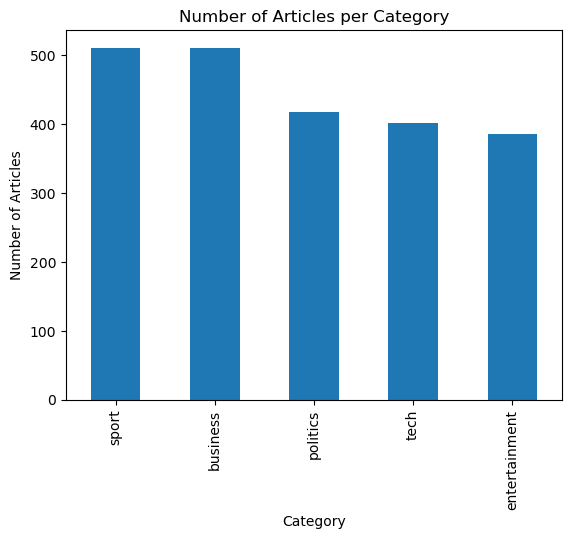

In [54]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Number of Articles per Category")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.show()


### Dataset Quality Assessment

#### Checking for missing values

In [59]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
text        0
label       0
informal    0
dtype: int64


#### Content cleanliness check with enhancements

In [74]:
noise_count = df["text"].str.contains(r"http|www|😂|🔥|lol|omg", regex=True).sum()
print("Number of articles with potential noise:", noise_count)

Number of articles with potential noise: 4


#### Source bias

In [71]:
print("All articles are sourced from BBC News.")
print("Note: The dataset may not represent other news outlets or social media content.")

All articles are sourced from BBC News.
Note: The dataset may not represent other news outlets or social media content.
